# Compute metrics

F1, recall, precision, mean IoU, mean Dice, PQ

Save metrics as:

results/experiment_metrics.csv


In [2]:
1+1

2

In [2]:
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from copy import deepcopy
import skimage
import scipy
import basicpy
from tqdm import tqdm

import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head')

from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl
from util import postprocessing as pp

%load_ext autoreload
%autoreload 2

In [3]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')
# organoid_sam = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam')

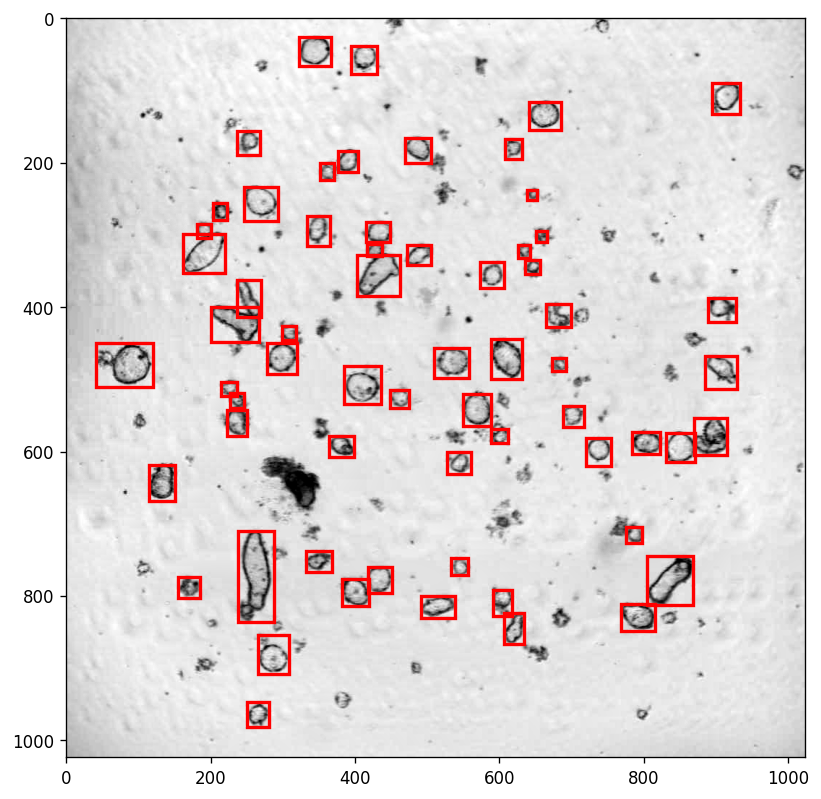

In [22]:
ds = dl.OrgaSegment(split='train')
im, mask, boxes, im_path, im_ID = ds[3]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

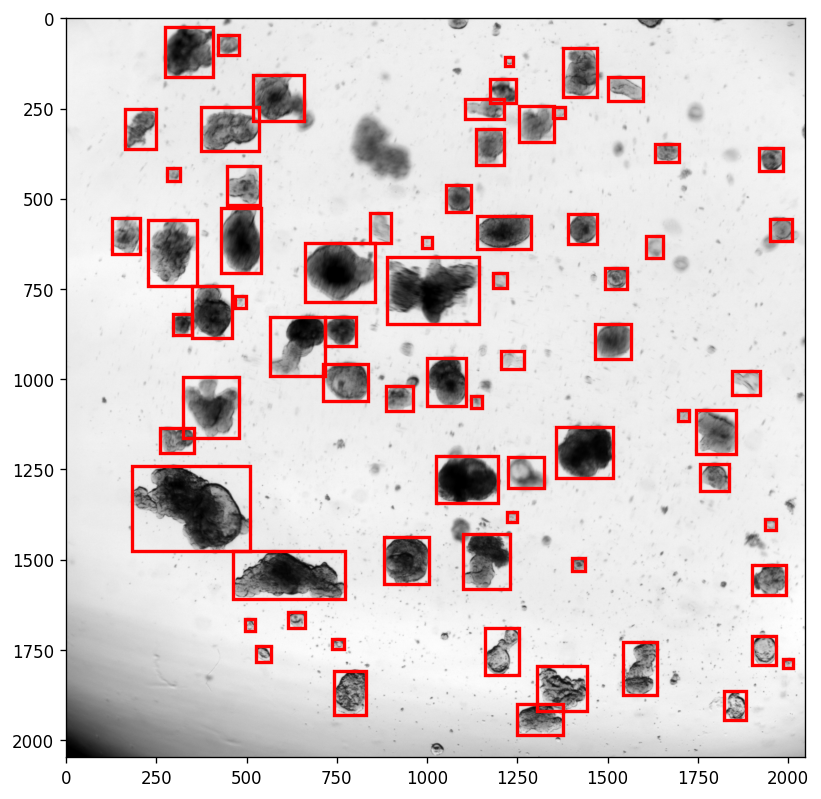

In [24]:
ds = dl.NewData(split='train')
im, mask, boxes, im_path, im_ID = ds[5]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

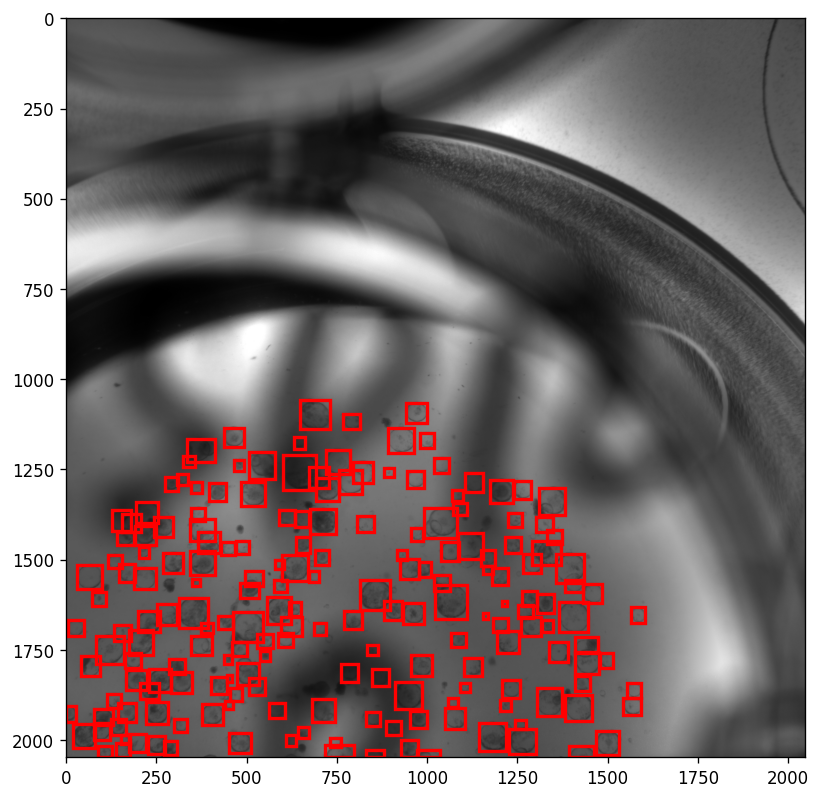

In [27]:
ds = dl.NewData(split='train')
im, mask, boxes, im_path, im_ID = ds[17]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

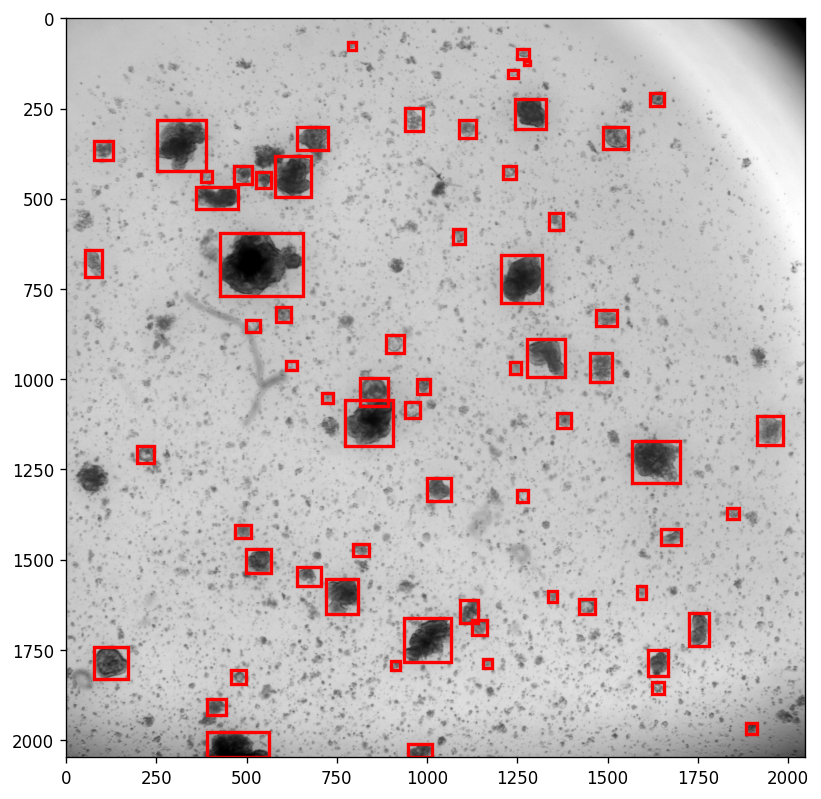

In [28]:
ds = dl.NewData(split='train')
im, mask, boxes, im_path, im_ID = ds[13]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

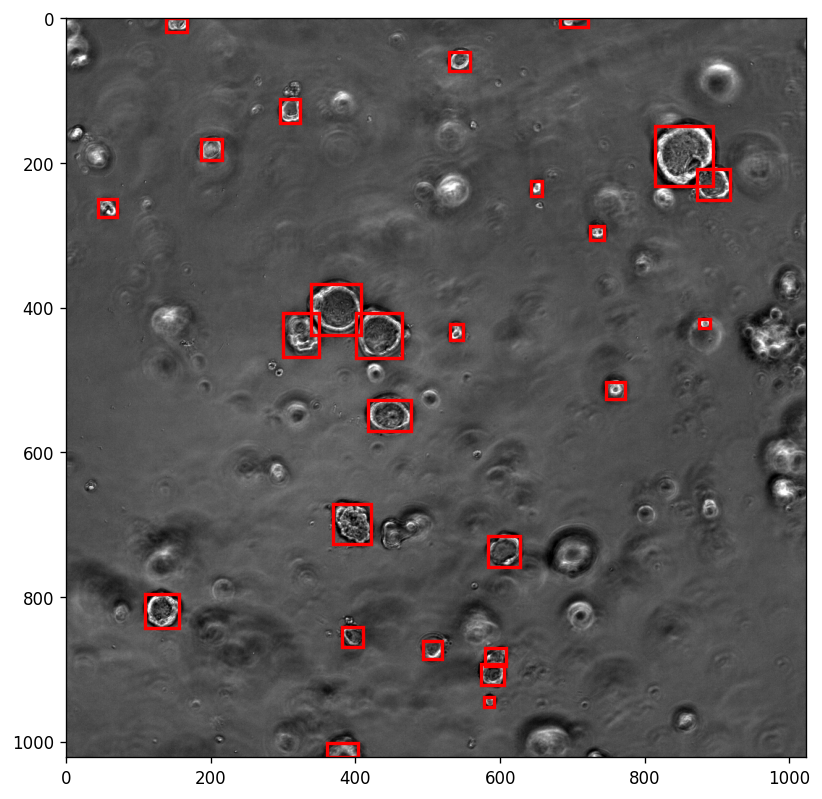

In [19]:
ds = dl.OrganoID(split='test')
im, mask, boxes, im_path, im_ID = ds[3]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

In [ ]:
# import detection_head_datamodule_copy as dhdm

In [ ]:
# data_module = DetectionHeadDataModule(
#                                         encoder_name='SAM_large', 
#                                         batch_size=32, 
#                                         train_dir_names=['OrganoID_train', 'MultiOrg_train_macros', 'MultiOrg_train_normal', 'OrgaExtractor_train', 'OrgaQuant_train', 'OrgaSegment_train', 'Tellu_train'],
#                                         val_dir_names=['OrganoID_val', 'MultiOrg_test_macros', 'MultiOrg_test_normal', 'OrgaExtractor_test', 'OrgaQuant_test', 'OrgaSegment_val', 'Tellu_val'],
#                                         batches_per_epoch=args.batches_per_epoch,
#                                         use_sampler=args.use_sampler,
#                                         balance_datasets=args.balance_datasets,
#                                         balance_validation=args.balance_validation,
#                                         balance_newdata=args.balance_newdata
#                                         )

In [21]:
split = 'test'
pred_folder = Path(f'/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_predictions/SAM_large/{split}/{str(ds)}_{ds.split}/DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_finetune_all_balanced_pre_OI_NeurIPS_True_32_200-best_epoch=299-val_loss=5.31')
pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, f'{str(ds)}_{ds.split}', pred_folder, im, im_ID)

In [ ]:
pred_masks.shape

(400, 1944, 2592)

In [7]:
(pred_masks.sum(axis=(1, 2)) < 100).sum()

0

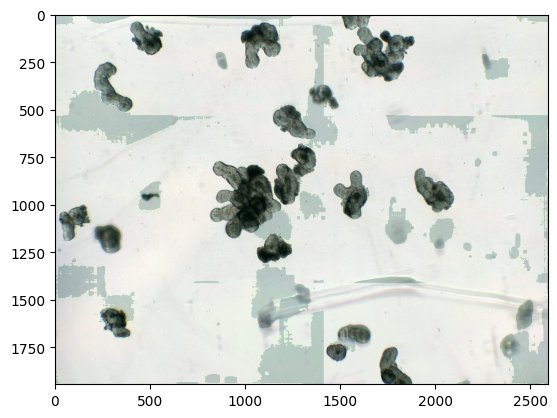

In [8]:
plt.imshow(im)
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255, alpha=0.2, cmap='YlGn')

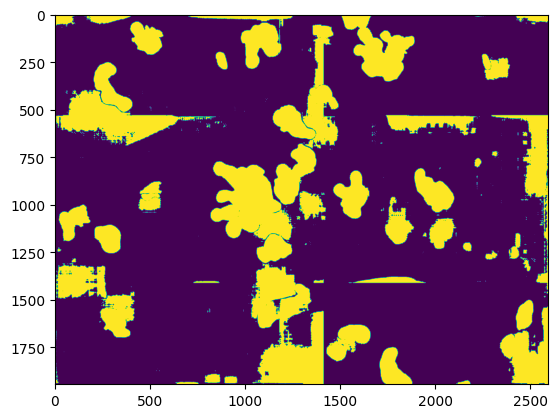

In [9]:
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255)

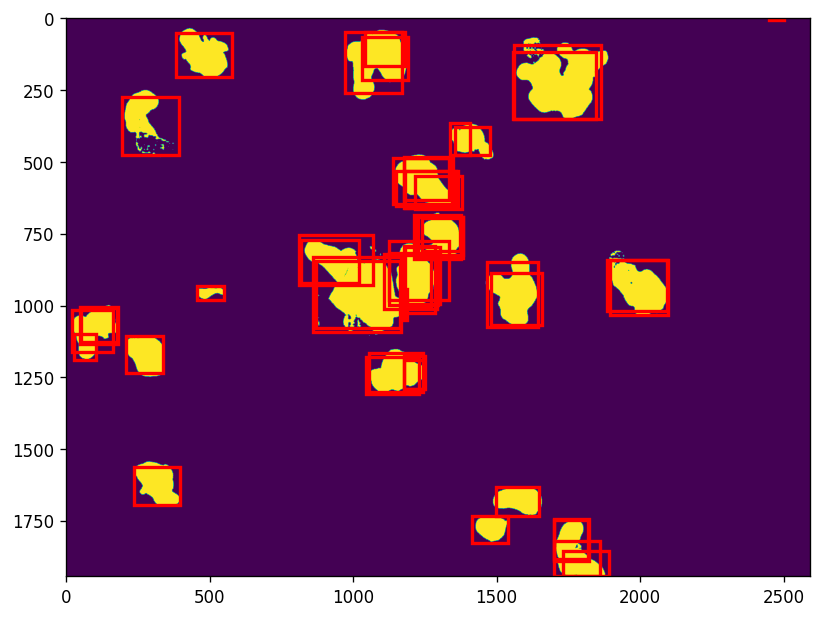

In [10]:
plot_boxes(np.any(pred_masks[pred_scores > 0.9], axis=0).astype(int) * 255, pred_boxes[pred_scores > 0.9], format='yxyx_px')
# plt.imshow(im)

In [9]:
dss = dl.NewData(split='train')
for idx, (im, mask, boxes, im_path, im_ID) in enumerate(dss):
    num_annotations = boxes.shape[0]
    print(f'Image {idx}:  [{im_ID}],  # annotations: {num_annotations}')

Image 0:  [04082023 R14 organoids_2x_RAW_ch00],  # annotations: 162
Image 1:  [2018-08-02_Tumour organoids_MT81 Tu Organoids Px16_1],  # annotations: 422
Image 2:  [2018-08-02_Tumour organoids_TM5807 Tu Organoids Px15 2-8-2018_2],  # annotations: 363
Image 3:  [2018-12-12 Before injections_ TM7722 T2-1 Px16_2_ch00],  # annotations: 50
Image 4:  [2018-12-12 Before injections_VPPK1176  Duo Px10_1_RAW_ch00],  # annotations: 51
Image 5:  [2019-01-24 CRC R17 Px4_Image001_RAW_ch00],  # annotations: 71
Image 6:  [2019-01-25 NSG425 T4 organoids Px3_Image003_RAW_ch00],  # annotations: 415
Image 7:  [2019-02-16 CRC R7_CRC R7 Px6_RAW_ch00],  # annotations: 61
Image 8:  [2019-02-26 A20 Px7_Image004_ch00],  # annotations: 289
Image 9:  [2019-09-06 MT651 T1-1 Px5_Image001_RAW_ch00],  # annotations: 53
Image 10:  [2019-09-06 MT651 T1-1 Px5_Image007_RAW_ch00],  # annotations: 27
Image 11:  [2019-09-30 NSG455 T4 Px2_Series004_RAW_ch00],  # annotations: 229
Image 12:  [2019-10-07 NSG464 T4-2 Px1_Image00

## Tune threshold

In [4]:

experiment_name = 'ablation_datasets_new'

In [ ]:

# NMS threshold
from tqdm import tqdm

nms_thres = 0.5



experiment = [
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_20_pre_OI_NeurIPS_True_32_200-best_epoch=449-val_loss=5.40', 'dataset_20', 'val', dl.OrganoID(split='test')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_10_pre_OI_NeurIPS_True_32_200-best_epoch=399-val_loss=5.30', 'dataset_10', 'val', dl.OrganoID(split='test')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_5_pre_OI_NeurIPS_True_32_200-best_epoch=449-val_loss=5.28', 'dataset_5', 'val', dl.OrganoID(split='test')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_2_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.38', 'dataset_2', 'val', dl.OrganoID(split='test')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_0_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.30', 'dataset_0', 'val', dl.OrganoID(split='test')),

    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_finetune_all_balanced_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.35', 'all_balanced_last', 'val', dl.OrganoID(split='val')),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_finetune_all_balanced_pre_OI_NeurIPS_True_32_200-best_epoch=299-val_loss=5.31', 'all_balanced_best', 'val', dl.OrganoID(split='val')),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_orig_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.98', 'public_orig_last', 'val', dl.OrganoID(split='val')),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_orig_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.98', 'public_orig_best', 'val', dl.OrganoID(split='val')),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_balanced_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.61', 'public_balanced_last', 'val', dl.OrganoID(split='val')),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_balanced_pre_OI_NeurIPS_True_32_200-best_epoch=399-val_loss=5.36', 'public_balanced_best', 'val', dl.OrganoID(split='val')),
]


df = []



for backbone, ckpt_name, model_name, _, _ in experiment:
    for split, test_data in [('val', dl.OrganoID(split='val')),
                             ('val', dl.OrgaQuant(split='test')),
                             ('val', dl.OrgaSegment(split='val')),
                             ('val', dl.Tellu(split='val')),
                             ('val', dl.OrgaExtractor(split='test')),
                             ]:
        iis = np.linspace(0, len(test_data) - 1, num=4, endpoint=True).round().astype(int).tolist()
    # if ckpt_name in df_partial['ckpt_name'].unique().flatten().tolist():
    #     print('skipping')
    #     continue

        ds_name = f'{str(test_data)}_{test_data.split}'
        
        pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
        for ii in tqdm(iis):
            im, mask, boxes, im_path, im_ID = test_data[ii]
            # gt_masks = pp.convert_mask_to_binary(mask)

            # offsets, pseudo_boxes, pseudo_scores, pseudo_masks = get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID)
            # pred_boxes, pred_scores, pred_masks = pseudo_boxes, pseudo_scores, pseudo_masks  # TODO: change
            # min_shape = min(pred_boxes.shape[0], pred_masks.shape[0])
            # pred_boxes = pred_boxes[:min_shape]
            # pred_masks = pred_masks[:min_shape]
            # pred_scores = pred_scores[:min_shape]

            # pred_boxes, pred_scores, pred_masks, is_border = get_predictions(split, ds_name, pred_base, im, im_ID)
            pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)

            print(pred_boxes.shape, boxes.shape)

            keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
            pred_boxes = pred_boxes[keep_masks]
            pred_masks = pred_masks[keep_masks]
            pred_scores = pred_scores[keep_masks]
            
            # print(pred_boxes.shape, boxes.shape)

            # Filter most unrealistic ones
            # lowest_score = 0.5
            sorted_scores = np.sort(pred_scores, axis=None)
            if len(sorted_scores) < 300:
                lowest_score = 0.0
            else:
                lowest_score = np.round(sorted_scores[-300], decimals=2) 
            print(lowest_score)
            if lowest_score > 0.95:
                print('\n##### Skipping evaluation due to very high score threshold. #####\n')
                continue

            pred_boxes = pred_boxes[pred_scores >= lowest_score]
            pred_masks = pred_masks[pred_scores >= lowest_score]
            pred_scores = pred_scores[pred_scores >= lowest_score]
            
            # print(pred_boxes.shape, boxes.shape)

            iou_matrix_detection = pp.compute_iou_matrix_detection(pred_boxes, gt_boxes=boxes)
            # print('after det')
            # iou_matrix_segmentation = pp.compute_iou_matrix_segmentation(pred_masks, gt_masks)
            # print('after seg')
            
            for confidence_thres in tqdm(np.arange(0.0, 1.0, 0.01)): 
            
                # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
            
                _pred_boxes = pred_boxes[pred_scores >= confidence_thres]
                _pred_scores = pred_scores[pred_scores >= confidence_thres]
                _iou_matrix_detection = iou_matrix_detection[pred_scores >= confidence_thres]
                # _iou_matrix_segmentation = iou_matrix_segmentation[pred_scores >= confidence_thres]
                
                # TODO: Remove boxes at patch borders

                kept_indices = pp.non_max_suppression(_pred_boxes, _pred_scores, threshold=nms_thres)
                # print('after nms')

                if len(kept_indices) != 0:
                    _iou_matrix_detection = _iou_matrix_detection[kept_indices]
                    # _iou_matrix_segmentation = _iou_matrix_segmentation[kept_indices]

                    # tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation_from_iou_matrix(
                    #     iou_matrix=_iou_matrix_segmentation, iou_threshold=0.5
                    # )
                    # df.append([experiment_name, 
                    #             f'{str(test_data)}_{test_data.split}', im_ID,
                    #             'segmentation', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                    #             tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                    
                    tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection_from_iou_matrix(
                        iou_matrix=_iou_matrix_detection, iou_threshold=0.5
                    )
                    df.append([experiment_name, 
                                f'{str(test_data)}_{test_data.split}', im_ID,
                                'detection', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                del _pred_boxes
                del _pred_scores
                del _iou_matrix_detection
                # del _iou_matrix_segmentation
            del pred_boxes
            del pred_masks
            del pred_scores
    df_partial = pd.DataFrame(data=df, columns=[
        'exp_name', 'testset', 'im_ID', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
        'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
    ])
    df_partial.to_csv(results_dir / f'thres_tuning_{experiment_name}_partial_full_val.csv')

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])

df.to_csv(results_dir / f'thres_tuning_{experiment_name}_full_val.csv')
df

  0%|                                                                                      | 0/4 [00:00<?, ?it/s]

(2500, 4) (95, 4)
0.22


 25%|███████████████████▌                                                          | 1/4 [00:10<00:30, 10.25s/it]

(2500, 4) (46, 4)
0.1


 50%|███████████████████████████████████████                                       | 2/4 [00:18<00:18,  9.11s/it]

...

(1500, 4) (78, 4)
0.44


 75%|██████████████████████████████████████████████████████████▌                   | 3/4 [00:22<00:07,  7.52s/it]

(1500, 4) (72, 4)
0.24


100%|██████████████████████████████████████████████████████████████████████████████| 4/4 [00:30<00:00,  7.51s/it]


,exp_name,testset,im_ID,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,ablation_datasets_new,OrganoID_val,0,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.00,61,145,34,0.0,0.296117,0.642105,0.405316,0.753768,0.0
1,ablation_datasets_new,OrganoID_val,0,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.01,61,145,34,0.0,0.296117,0.642105,0.405316,0.753768,0.0
2,ablation_datasets_new,OrganoID_val,0,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.02,61,145,34,0.0,0.296117,0.642105,0.405316,0.753768,0.0
3,ablation_datasets_new,OrganoID_val,0,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.03,61,145,34,0.0,0.296117,0.642105,0.405316,0.753768,0.0
4,ablation_datasets_new,OrganoID_val,0,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.04,61,145,34,0.0,0.296117,0.642105,0.405316,0.753768,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ablation_datasets_new,OrgaExtractor_test,input_30,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.95,67,43,5,0.0,0.609091,0.930556,0.736264,0.891048,0.0
9996,ablation_datasets_new,OrgaExtractor_test,input_30,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.96,65,41,7,0.0,0.613208,0.902778,0.730337,0.895903,0.0
9997,ablation_datasets_new,OrgaExtractor_test,input_30,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.97,62,35,10,0.0,0.639175,0.861111,0.733728,0.899405,0.0
9998,ablation_datasets_new,OrgaExtractor_test,input_30,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.98,60,22,12,0.0,0.731707,0.833333,0.779221,0.900542,0.0


In [12]:
# df_partial = pd.read_csv(results_dir / f'thres_tuning_{experiment_name}_partial_full_val.csv')
# df_partial = df_partial.drop(columns='Unnamed: 0')
# df_partial

In [13]:
# df = pd.concat([df, df_partial], axis=0, ignore_index=True)
# df

In [ ]:
# df.to_csv(results_dir / f'thres_tuning_{experiment_name}_full_val.csv')

In [14]:
metrics = df.groupby(['exp_name', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres'], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics

,exp_name,metric_type,backbone,ckpt_name,model_name,confidence_thres,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.00,0.0,0.262190,0.928061,0.383917,0.819146,0.0
1,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.01,0.0,0.266237,0.928061,0.390913,0.819146,0.0
2,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.02,0.0,0.273457,0.928061,0.402089,0.819146,0.0
3,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.03,0.0,0.278831,0.928061,0.409859,0.819146,0.0
4,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.04,0.0,0.284629,0.928061,0.418066,0.819146,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.95,0.0,0.611648,0.791431,0.670567,0.823905,0.0
496,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,0.0,0.632154,0.767832,0.672307,0.823578,0.0
497,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.97,0.0,0.656910,0.724415,0.664392,0.826647,0.0
498,ablation_datasets_new,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.98,0.0,0.682943,0.646362,0.635798,0.832778,0.0


In [15]:
det_df = metrics.loc[metrics.metric_type == 'detection']
det_df_max = det_df.groupby(['model_name', 'ckpt_name'], as_index=False).agg(
    max_f1 = ('f1_score_mean', 'max')
    #lambda x: x[x['f1_score_mean'] == x['f1_score_mean'].max(), 'confidence_thres'].item()
)
det_df = det_df.join(det_df_max.set_index(['model_name', 'ckpt_name']), on=['model_name', 'ckpt_name'], how='left')
best_thres_df = det_df.loc[det_df['f1_score_mean'] == det_df['max_f1'], ['model_name', 'confidence_thres', 'max_f1']]
best_thres_df

,model_name,confidence_thres,max_f1
96,dataset_0,0.96,0.686067
197,dataset_10,0.97,0.664489
298,dataset_20,0.98,0.669293
396,dataset_2,0.96,0.685669
496,dataset_5,0.96,0.672307


In [16]:
# det_df = metrics.loc[metrics.metric_type == 'detection']
# det_df_max = det_df.groupby(['model_name', 'ckpt_name'], as_index=False).agg(
#     max_f1 = ('f1_score_mean', 'max')
#     #lambda x: x[x['f1_score_mean'] == x['f1_score_mean'].max(), 'confidence_thres'].item()
# )
# det_df = det_df.join(det_df_max.set_index(['model_name', 'ckpt_name']), on=['model_name', 'ckpt_name'], how='left')
# best_thres_df = det_df.loc[det_df['f1_score_mean'] == det_df['max_f1'], ['model_name', 'confidence_thres', 'max_f1']]
# best_thres_df

In [17]:
best_thres_df.to_csv(results_dir / f'best_thres_df_{experiment_name}_full_val.csv')

In [6]:
best_thres_df = pd.read_csv(results_dir / f'best_thres_df_{experiment_name}_full_val.csv')

# Predict

boxes, scores and masks are saved in a folder called 'organoid_sam/patch_predictions/backbone/trainvaltest/dataset_name/checkpoint_name/image_ID/boxes_{i}.npy'

In [7]:
best_thres_df

,Unnamed: 0,model_name,confidence_thres,max_f1
0,96,dataset_0,0.96,0.686067
1,197,dataset_10,0.97,0.664489
2,298,dataset_20,0.98,0.669293
3,396,dataset_2,0.96,0.685669
4,496,dataset_5,0.96,0.672307


In [ ]:
# NMS threshold
from tqdm import tqdm


nms_thres = 0.5

experiment = [
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_20_pre_OI_NeurIPS_True_32_200-best_epoch=449-val_loss=5.40', 'dataset_20'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_10_pre_OI_NeurIPS_True_32_200-best_epoch=399-val_loss=5.30', 'dataset_10'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_5_pre_OI_NeurIPS_True_32_200-best_epoch=449-val_loss=5.28', 'dataset_5'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_2_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.38', 'dataset_2'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_0_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.30', 'dataset_0'),

    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_finetune_all_balanced_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.35', 'all_balanced_last'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_finetune_all_balanced_pre_OI_NeurIPS_True_32_200-best_epoch=299-val_loss=5.31', 'all_balanced_best'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_orig_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.98', 'public_orig_last'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_orig_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.98', 'public_orig_best'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_balanced_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.61', 'public_balanced_last'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_balanced_pre_OI_NeurIPS_True_32_200-best_epoch=399-val_loss=5.36', 'public_balanced_best'),
]


df = []
for split, test_data in [('test', dl.OrganoID(split='test')),
                    ('test', dl.OrganoID(split='test_Lung')),
                    ('test', dl.OrganoID(split='test_ACC')),
                    ('test', dl.OrganoID(split='test_C')),
                    ('test', dl.OrganoID(split='test_only_mouse'))]:
    for backbone, ckpt_name, model_name in experiment:
        optimal_thres = float(best_thres_df.loc[best_thres_df['model_name'] == model_name, 'confidence_thres'].item())
        print(optimal_thres)
        
        ds_name = f'{str(test_data)}_{test_data.split}'
        
        pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
        for im, mask, boxes, im_path, im_ID in tqdm(test_data):
            gt_masks = pp.convert_mask_to_binary(mask)

            pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            pred_boxes = pred_boxes[pred_scores >= optimal_thres]
            pred_masks = pred_masks[pred_scores >= optimal_thres]
            pred_patch_numbers = pred_patch_numbers[pred_scores >= optimal_thres]
            pred_offsets = pred_offsets[pred_scores >= optimal_thres]
            pred_scores = pred_scores[pred_scores >= optimal_thres]


            keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
            pred_boxes = pred_boxes[keep_masks]
            pred_masks = pred_masks[keep_masks]
            pred_patch_numbers = pred_patch_numbers[keep_masks]
            pred_offsets = pred_offsets[keep_masks]
            pred_scores = pred_scores[keep_masks]
            
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(pred_boxes, pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                pred_boxes = pred_boxes[kept_indices]
                pred_masks = pred_masks[kept_indices]
                pred_patch_numbers = pred_patch_numbers[kept_indices]
                pred_offsets = pred_offsets[kept_indices]
                pred_scores = pred_scores[kept_indices]

                pred_masks, pred_boxes, pred_scores = pp.stitch(pred_masks, 
                                                                pred_patch_numbers, 
                                                                pred_offsets, 
                                                                pred_boxes, 
                                                                pred_scores)

                assert pred_boxes.ndim == 2, pred_boxes.shape
                assert pred_boxes.shape[1] == 4, pred_boxes.shape
                assert pred_boxes.shape[0] == pred_masks.shape[0], pred_masks.shape
                assert pred_boxes.shape[0] == pred_scores.shape[0], pred_scores.shape

                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation(pred_masks=pred_masks, 
                                                                                                                       gt_masks=gt_masks, 
                                                                                                                       iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'segmentation', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection(pred_boxes=pred_boxes, 
                                                                                                                    gt_boxes=boxes, 
                                                                                                                    iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'detection', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
    df_partial = pd.DataFrame(data=df, columns=[
        'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
        'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
    ])
    df_partial.to_csv(results_dir / f'organoID_test_{experiment_name}_partial_results.csv')
    del df_partial

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres.csv')
df

0.98


100%|████████████████████████████████████████████████████████████████████████████| 10/10 [02:01<00:00, 12.19s/it]


0.97


100%|████████████████████████████████████████████████████████████████████████████| 10/10 [02:12<00:00, 13.24s/it]


0.96


...

0.96


100%|██████████████████████████████████████████████████████████████████████████████| 4/4 [00:44<00:00, 11.13s/it]


0.96


100%|██████████████████████████████████████████████████████████████████████████████| 4/4 [00:49<00:00, 12.46s/it]


,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,ablation_datasets_new,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.98,36,6,144,0.269622,0.857143,0.200000,0.324324,0.831333,0.904146
1,ablation_datasets_new,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.98,34,8,146,0.000000,0.809524,0.188889,0.306306,0.780312,0.000000
2,ablation_datasets_new,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.98,48,2,31,0.642467,0.960000,0.607595,0.744186,0.863315,0.923483
3,ablation_datasets_new,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.98,47,3,32,0.000000,0.940000,0.594937,0.728682,0.805040,0.000000
4,ablation_datasets_new,OrganoID_test,PDAC2,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.98,41,2,13,0.721390,0.953488,0.759259,0.845361,0.853352,0.918176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,ablation_datasets_new,OrganoID_test_mouse,b_image0009,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.96,11,3,7,0.000000,0.785714,0.611111,0.687500,0.792459,0.000000
316,ablation_datasets_new,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.96,30,4,52,0.434822,0.882353,0.365854,0.517241,0.840657,0.910251
317,ablation_datasets_new,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.96,29,5,53,0.000000,0.852941,0.353659,0.500000,0.739474,0.000000
318,ablation_datasets_new,OrganoID_test_mouse,image0017,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.96,14,2,4,0.727850,0.875000,0.777778,0.823529,0.883818,0.937162


In [63]:
sel_imgs = df[df.metric_type == 'segmentation']
sel_imgs = sel_imgs[sel_imgs.testset.isin(['OrganoID_test', 'OrganoID_test_mouse'])]
sel_imgs = sel_imgs[sel_imgs.model_name == 'dataset_5']
sel_imgs

,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
40,ablation_datasets_new,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,46,18,134,0.301630,0.718750,0.255556,0.377049,0.799976,0.884280
42,ablation_datasets_new,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,57,5,22,0.707146,0.919355,0.721519,0.808511,0.874628,0.931479
44,ablation_datasets_new,OrganoID_test,PDAC2,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,48,7,6,0.755989,0.872727,0.888889,0.880734,0.858363,0.921923
46,ablation_datasets_new,OrganoID_test,PDAC3,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,24,16,2,0.553800,0.600000,0.923077,0.727273,0.761474,0.859415
48,ablation_datasets_new,OrganoID_test,PDAC4,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,18,4,4,0.706857,0.818182,0.818182,0.818182,0.863936,0.924699
50,ablation_datasets_new,OrganoID_test,PDAC5,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,23,8,4,0.625286,0.741935,0.851852,0.793103,0.788404,0.877143
52,ablation_datasets_new,OrganoID_test,PDAC6,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,19,1,14,0.629066,0.950000,0.575758,0.716981,0.877382,0.933666
54,ablation_datasets_new,OrganoID_test,PDAC7,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,20,2,18,0.539969,0.909091,0.526316,0.666667,0.809954,0.889935
56,ablation_datasets_new,OrganoID_test,PDAC8,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,36,13,15,0.603979,0.734694,0.705882,0.720000,0.838860,0.908251
58,ablation_datasets_new,OrganoID_test,PDAC9,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,61,7,52,0.582817,0.897059,0.539823,0.674033,0.864672,0.924776


In [64]:
sel_imgs.groupby(['testset']).agg(
    median_pq = ('pq', 'median')
)

,median_pq
testset,
OrganoID_test,0.614633
OrganoID_test_mouse,0.639013


In [60]:
print(f'organoID_test_{experiment_name}_correct_conf_thres')

organoID_test_ablation_datasets_new_correct_conf_thres


In [ ]:
# df = pd.read_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres.csv')

In [20]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', #'confidence_thres'
                      ], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics.head(40)

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,ablation_datasets_new,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.000000,0.806900,0.628578,0.688826,0.784993,0.000000
1,ablation_datasets_new,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_10,0.000000,0.806420,0.620173,0.676265,0.787538,0.000000
2,ablation_datasets_new,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.000000,0.852921,0.560541,0.650642,0.793474,0.000000
3,ablation_datasets_new,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_2,0.000000,0.827254,0.662400,0.706992,0.784488,0.000000
4,ablation_datasets_new,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.000000,0.795604,0.666802,0.703407,0.790176,0.000000
5,ablation_datasets_new,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_0,0.589984,0.830233,0.644437,0.706170,0.833608,0.905570
6,ablation_datasets_new,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_10,0.579946,0.834596,0.641724,0.698497,0.828624,0.901904
7,ablation_datasets_new,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_20,0.566612,0.883888,0.588404,0.678733,0.835990,0.906761
8,ablation_datasets_new,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_2,0.598743,0.839913,0.675935,0.718444,0.831036,0.903763
9,ablation_datasets_new,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.600654,0.816179,0.680685,0.718253,0.833765,0.905557


In [21]:
metrics.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres_aggregated.csv')
# metrics.head(40)

In [61]:
print(f'organoID_test_{experiment_name}_correct_conf_thres_aggregated')

organoID_test_ablation_datasets_new_correct_conf_thres_aggregated


In [23]:
pq_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
).loc[['dataset_0', 'dataset_2', 'dataset_5', 'dataset_10', 'dataset_20'], :]
# pq_metrics.to_csv(results_dir / f'{experiment_name}_PQ.csv')
pq_metrics #.loc[['MicroSAM_base_best', 'SAM2_large_best', 'SAM_large_best', 'SAM_base_best'], :]

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
dataset_0,0.589984,0.614581,0.721033,0.834300,0.605430
dataset_2,0.598743,0.636255,0.709771,0.829018,0.600368
dataset_5,0.600654,0.641483,0.727169,0.821686,0.637314
dataset_10,0.579946,0.589522,0.717435,0.825609,0.585154
dataset_20,0.566612,0.542839,0.737078,0.779445,0.577615


In [58]:
import matplotlib

plt.style.use('ggplot')

base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')

col_width_inch = 3.25
twocol_width_inch = 6.875

dpi=250
matplotlib.rcParams['figure.dpi'] = dpi
matplotlib.rcParams['font.size'] = 4

def plot_metric(table, metric='pq_mean', ylabel='Panoptic Quality'):
    table = table[table.metric_type=='segmentation']
    table = table[table.model_name.isin(['dataset_0', 'dataset_2', 'dataset_5', 'dataset_10', 'dataset_20'])]

    table = table.replace({
        'dataset_0': '0 % SAMOS data', 
        'dataset_2': '2 % SAMOS data', 
        'dataset_5': '5 % SAMOS data', 
        'dataset_10': '10 % SAMOS data', 
        'dataset_20': '20 % SAMOS data',
        'OrganoID_test': 'PDAC', 
        'OrganoID_test_Lung': 'Lung', 
        'OrganoID_test_ACC': 'ACC', 
        'OrganoID_test_C': 'Colon', 
        'OrganoID_test_mouse': 'Mouse'
    })

    table = table.pivot(
        index='model_name', columns='testset', values=metric
    ).loc[['0 % SAMOS data', '2 % SAMOS data', '5 % SAMOS data', '10 % SAMOS data', '20 % SAMOS data'], :]

    
    # Define organoid types and models
    organoid_types = ['PDAC', 'Lung', 'ACC', 'Colon', 'Mouse']
    models = ['0 % SAMOS data', '2 % SAMOS data', '5 % SAMOS data', '10 % SAMOS data', '20 % SAMOS data']

    # Extract PQ values for each model and organoid type
    # pq_values_by_type = {organoid: table[models, organoid].values 
    #                      for organoid in organoid_types}

    # Bar width and x-axis positions
    bar_width = 0.18
    x = np.arange(len(organoid_types))

    # Define color map
    color_map = {
        '0 % SAMOS data': (203/255, 233/255, 157/255),      # Light Green
        '2 % SAMOS data': (135/255, 207/255, 164/255),      # Soft Teal
        '5 % SAMOS data': (70/255, 158/255, 180/255),  # Bright Teal
        '10 % SAMOS data': (78/255, 98/255, 171/255),  # Deep Purple
        '20 % SAMOS data': (80/255, 80/255, 80/255),  # Dark Grey
    }

    # Set global font sizes
    plt.rcParams['font.size'] = 12         
    plt.rcParams['axes.labelsize'] = 14     
    plt.rcParams['xtick.labelsize'] = 12    
    plt.rcParams['ytick.labelsize'] = 12    
    plt.rcParams['legend.fontsize'] = 11    
    plt.rcParams['legend.title_fontsize'] = 13  

    # Plotting
    plt.figure(figsize=(8, 5))

    # Plot each model's bars with an offset for each organoid type
    for i, model in enumerate(models):
        # pq_values = [pq_values_by_type[organoid][i] for organoid in organoid_types]
        pq_values = table.loc[model, organoid_types].values
        plt.bar(x + i * bar_width, pq_values, bar_width, label=model, color=color_map[model])

    # Labeling and legend
    plt.xlabel('Organoid type', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(x + bar_width * 2.0, organoid_types)  # Adjust x-ticks to align with bars
    plt.legend(title='Training set', loc='lower right')
    plt.tight_layout()

    # Save the plot as PDF
    (results_dir / 'plots').mkdir(exist_ok=True)
    plt.savefig(results_dir / 'plots' / f'ablation_{experiment_name}_{metric}.pdf', format='pdf', dpi=300)
    plt.savefig(results_dir / 'plots' / f'ablation_{experiment_name}_{metric}.png', format='png', dpi=300)

    # Display the plot
    plt.show()


In [59]:
# metrics

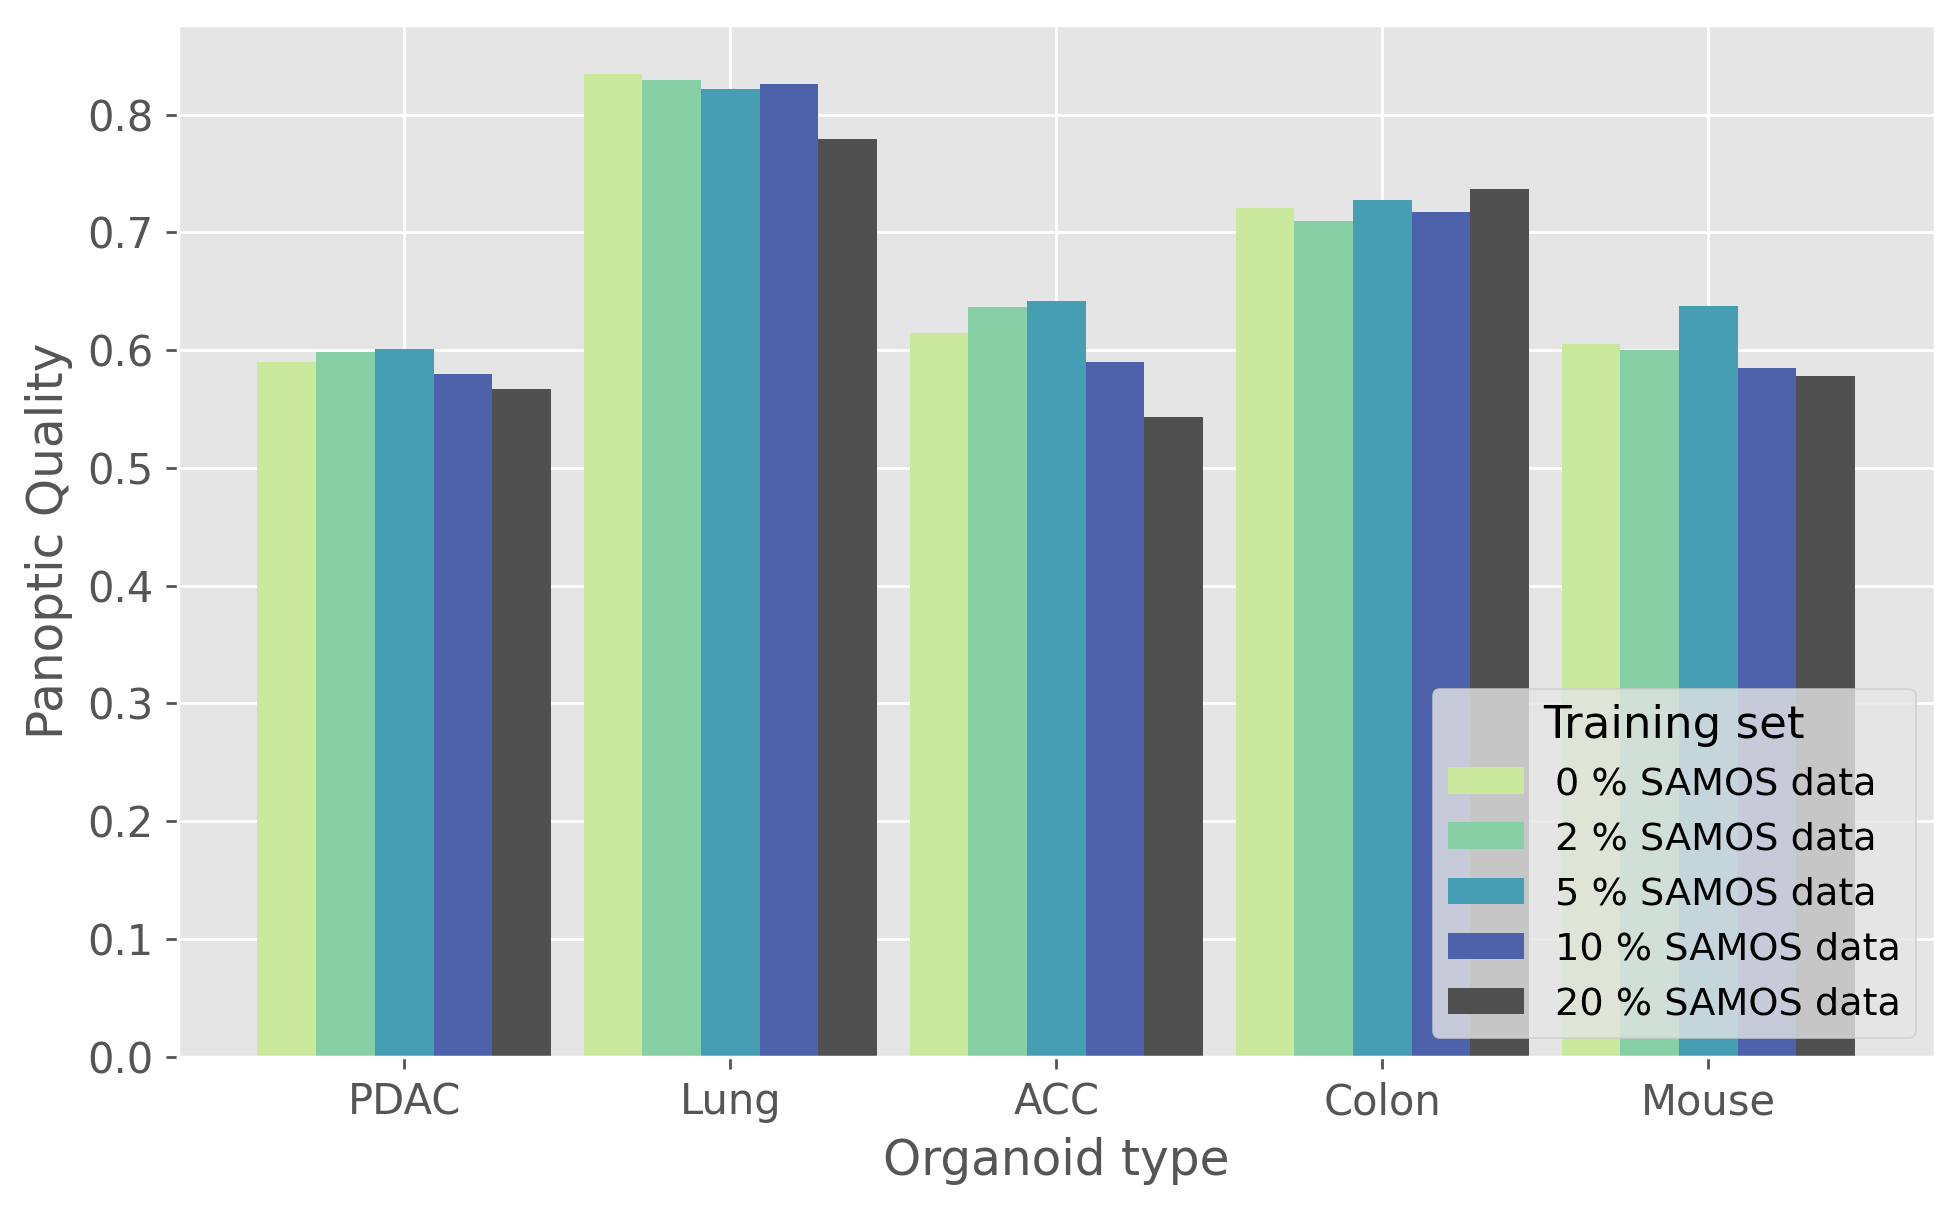

In [ ]:
plot_metric(table=metrics, metric='pq_mean', ylabel='Panoptic Quality')

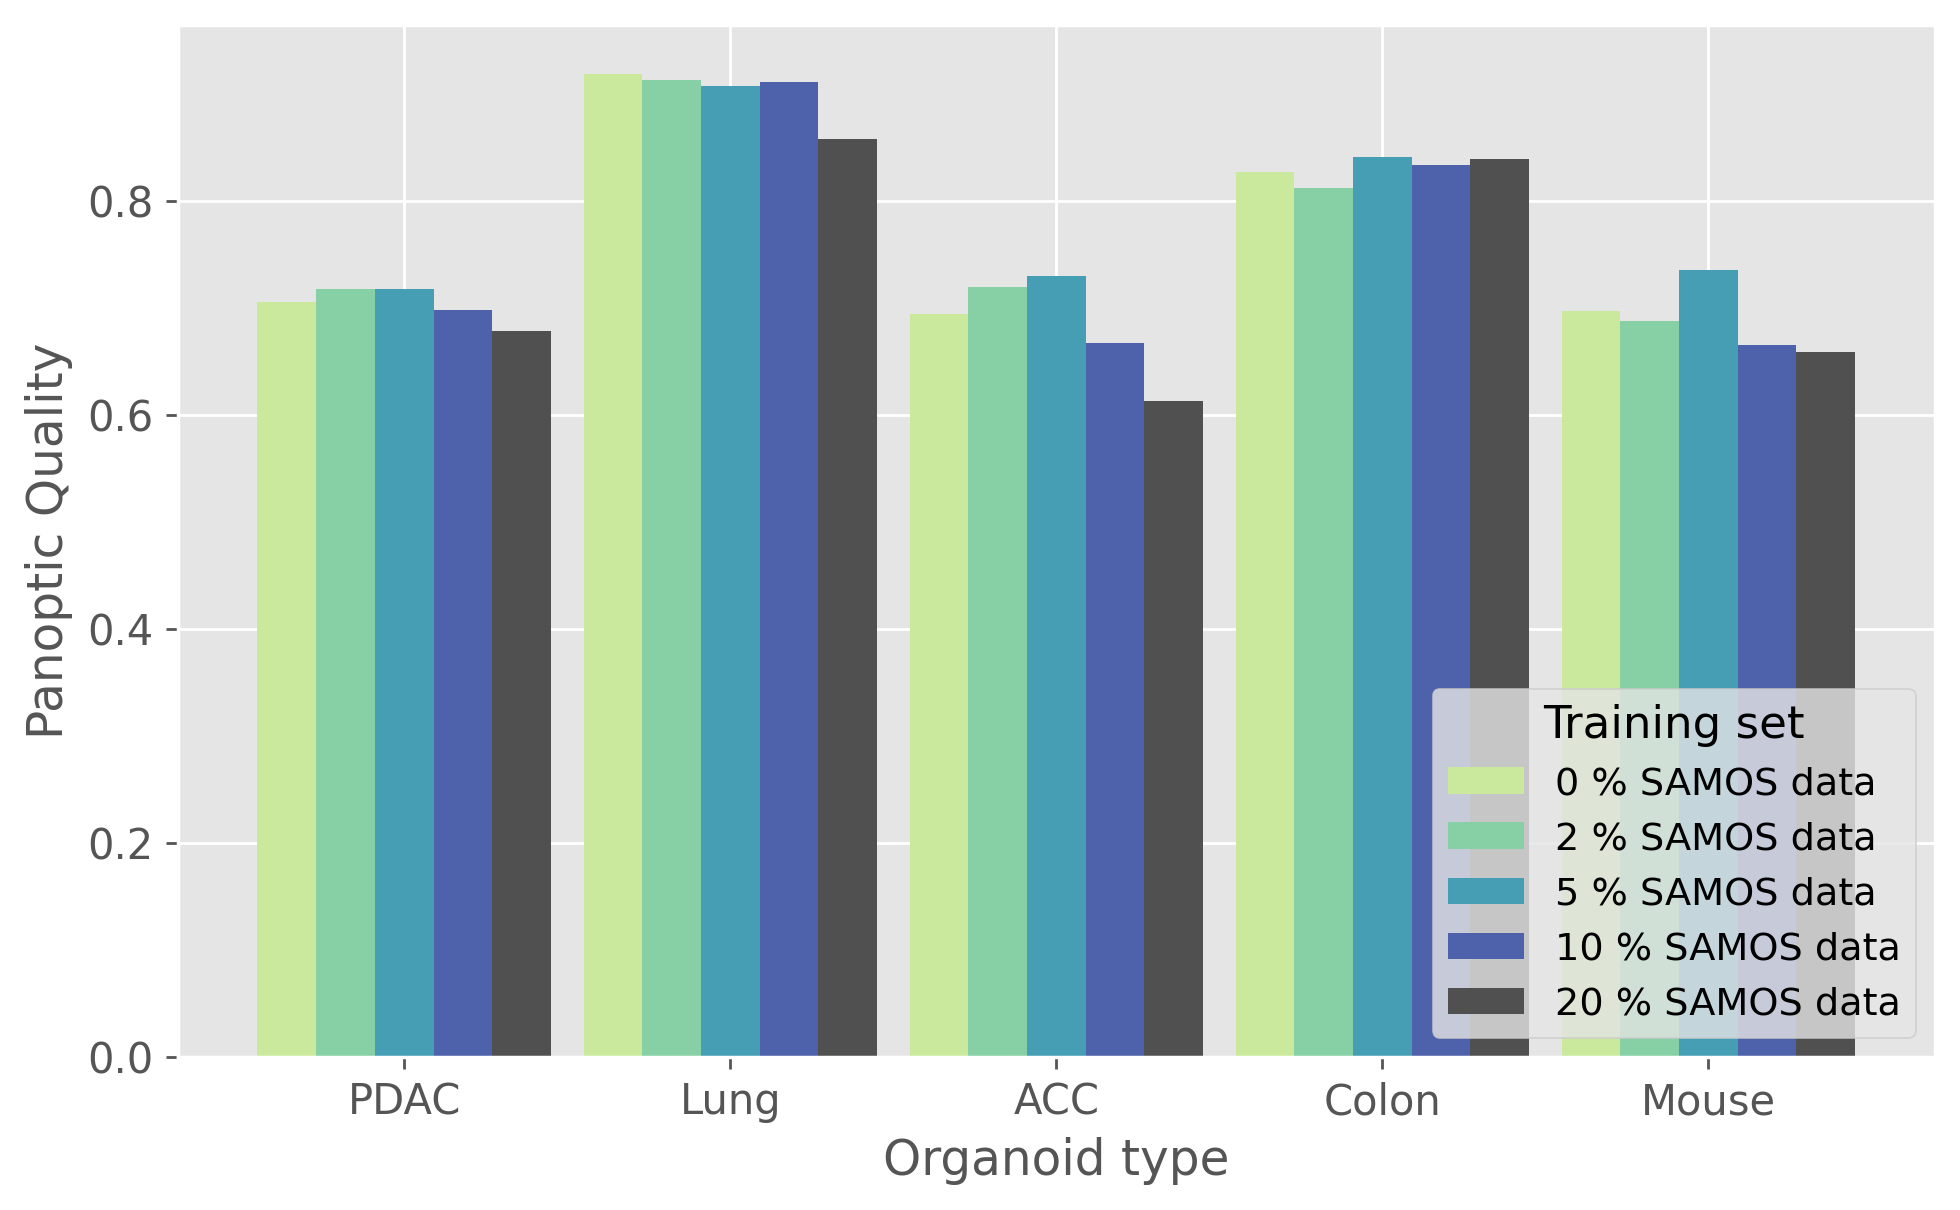

In [56]:
plot_metric(table=metrics, metric='f1_score_mean')

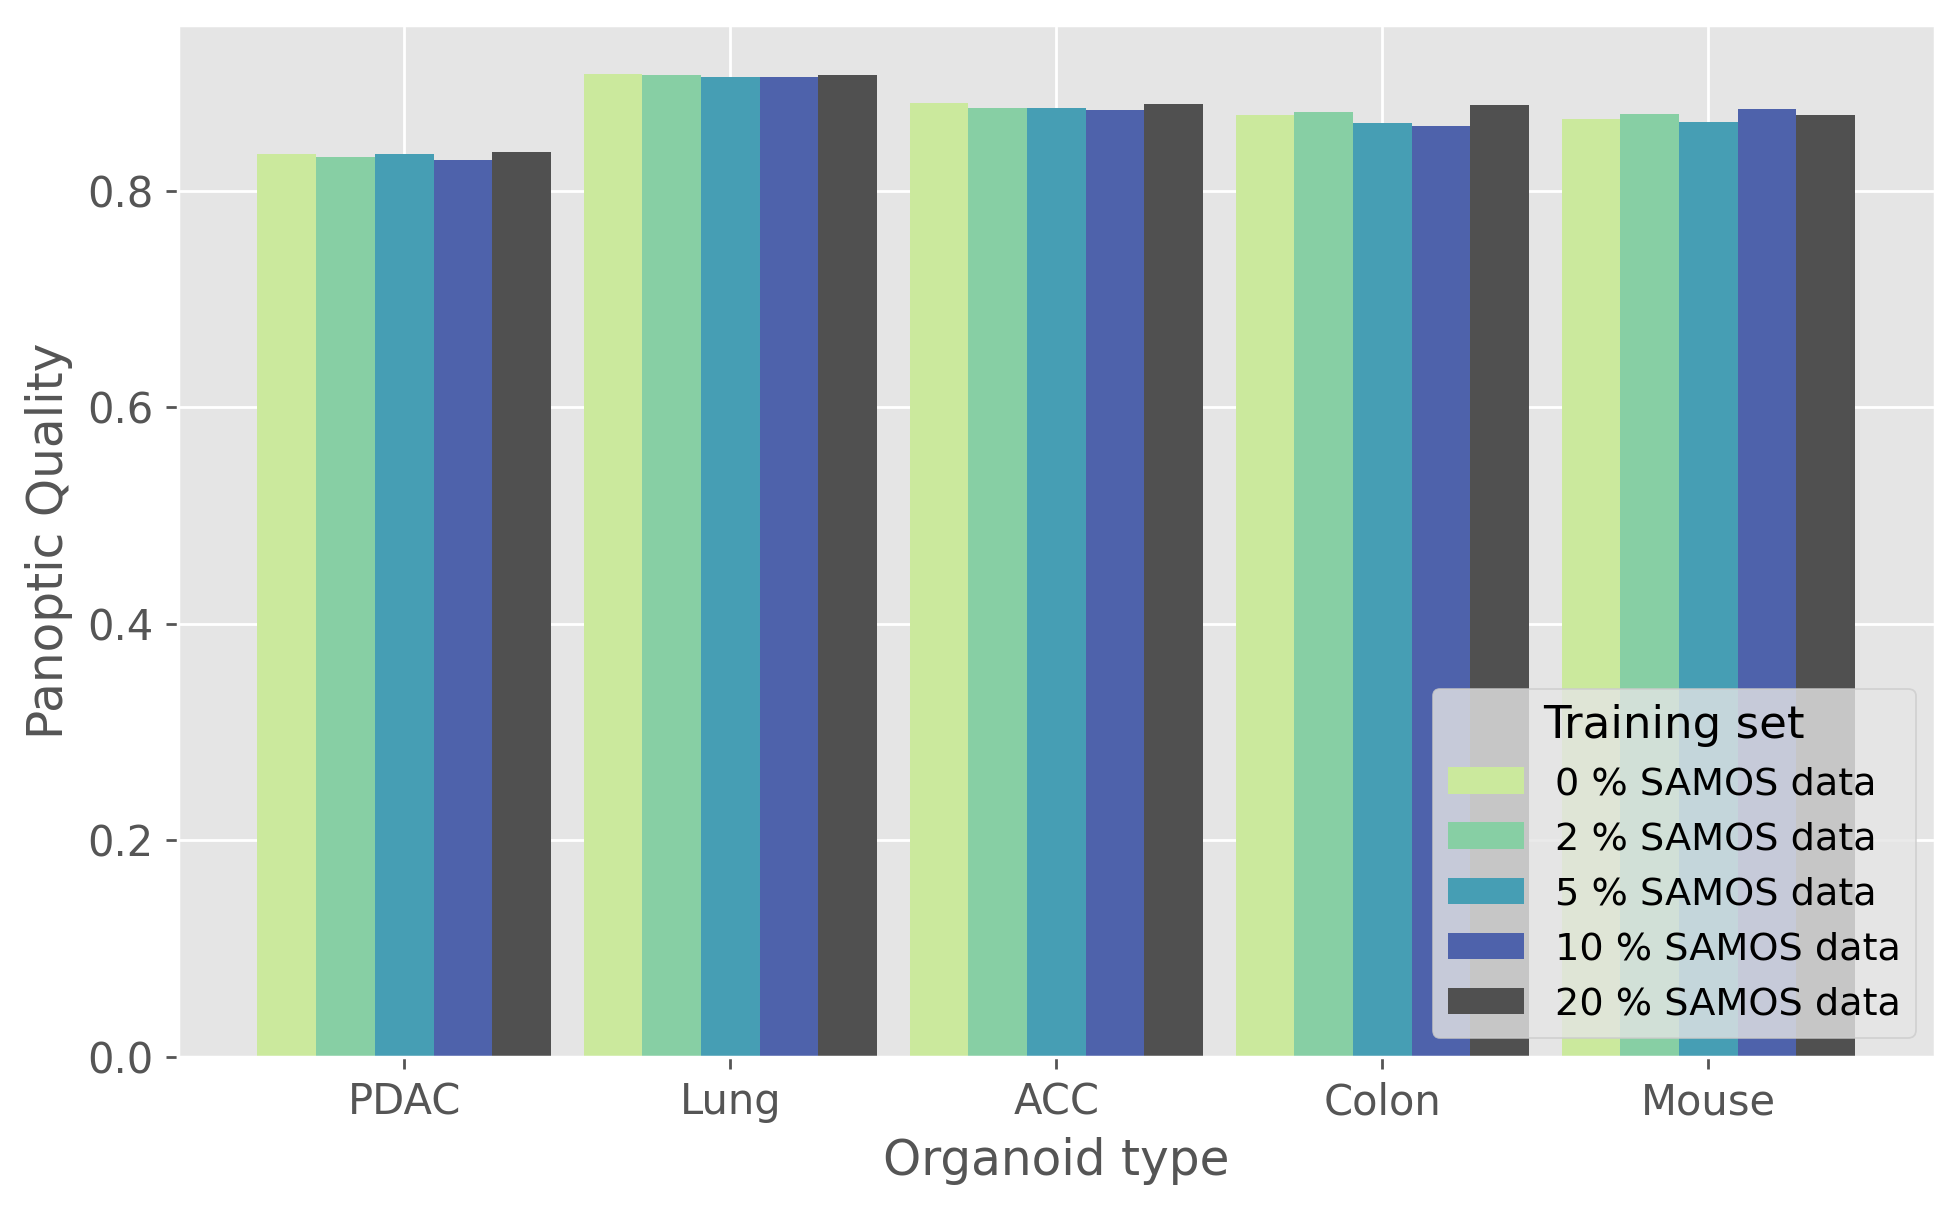

In [57]:
plot_metric(table=metrics, metric='mean_iou_mean')

In [ ]:
pq_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
).loc[['CellSAM_best', 'MedSAM_best', 'MicroSAM_base_best', 'MicroSAM_large_best', 'MicroSAM_huge_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
pq_metrics.to_csv(results_dir / f'{experiment_name}_PQ.csv')
pq_metrics #.loc[['MicroSAM_base_best', 'SAM2_large_best', 'SAM_large_best', 'SAM_base_best'], :]

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
CellSAM_best,0.197018,0.214435,0.250819,0.445552,0.015023
MedSAM_best,0.222629,0.255354,0.257479,0.410882,0.121487
MicroSAM_base_best,0.532192,0.566320,0.536982,0.759669,0.371441
MicroSAM_large_best,0.474462,0.488720,0.588228,0.692021,0.408004
MicroSAM_huge_best,0.471023,0.527107,0.507411,0.692646,0.379354
SAM_base_best,0.486851,0.593540,0.436241,0.736352,0.583274
SAM_large_best,0.500034,0.618009,0.555269,0.791746,0.542728
SAM2_large_best,0.560355,0.557548,0.604707,0.740009,0.457462


In [ ]:

pq_metrics_ = pd.read_csv(results_dir / f'ablation_dataset_PQ.csv')
pq_metrics #.loc[['MicroSAM_base_best', 'SAM2_large_best', 'SAM_large_best', 'SAM_base_best'], :]

In [ ]:
f1_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='f1_score_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
f1_metrics.to_csv(results_dir / 'ablation_SAM_variants_F1_subset.csv')
f1_metrics

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.665814,0.687263,0.655538,0.879190,0.512109
SAM_base_best,0.597220,0.685502,0.502781,0.833945,0.706133
SAM_large_best,0.591267,0.725582,0.595997,0.861216,0.665041
SAM2_large_best,0.682654,0.659888,0.715416,0.829858,0.585937


In [8]:
f1_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='f1_score_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
f1_metrics.to_csv(results_dir / 'ablation_SAM_variants_F1_subset.csv')
f1_metrics

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.668858,0.687263,0.664234,0.876722,0.512109
SAM_base_best,0.610868,0.690276,0.522232,0.837448,0.706133
SAM_large_best,0.612436,0.726062,0.649338,0.870567,0.665041
SAM2_large_best,0.698366,0.659888,0.728559,0.844337,0.585937


In [ ]:
mean_iou_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='mean_iou_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
mean_iou_metrics.to_csv(results_dir / 'ablation_SAM_variants_Mean_IoU_subset.csv')
mean_iou_metrics

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.789321,0.817503,0.808309,0.863387,0.713780
SAM_base_best,0.788577,0.857958,0.831899,0.877994,0.825246
SAM_large_best,0.809683,0.849978,0.853562,0.909865,0.814600
SAM2_large_best,0.798173,0.844022,0.829588,0.875867,0.780981


In [9]:
mean_iou_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='mean_iou_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
mean_iou_metrics.to_csv(results_dir / 'ablation_SAM_variants_Mean_IoU_subset.csv')
mean_iou_metrics

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.792958,0.817503,0.808309,0.865053,0.713780
SAM_base_best,0.789020,0.857958,0.831899,0.877994,0.825246
SAM_large_best,0.812270,0.851698,0.853562,0.909587,0.814600
SAM2_large_best,0.799921,0.844022,0.829588,0.875867,0.780981


### Plots

In [24]:
metrics_orgasegment_ours = pd.read_csv(results_dir / f'organoID_test_orgasegment_comparison_correct_conf_thres_aggregated.csv')
metrics_orgasegment_ours.head(40)

,Unnamed: 0,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,0,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.000000,0.565898,0.470829,0.486638,0.715293,0.000000
1,1,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.000000,0.592947,0.488204,0.511908,0.712827,0.000000
2,2,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_best,0.000000,0.697032,0.468219,0.542019,0.735094,0.000000
3,3,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_last,0.000000,0.713663,0.442126,0.528173,0.729683,0.000000
4,4,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_best,0.000000,0.717021,0.491438,0.547886,0.742746,0.000000
5,5,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_last,0.000000,0.689223,0.474995,0.529849,0.746580,0.000000
6,6,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.000000,0.693883,0.573620,0.599545,0.749804,0.000000
7,7,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.000000,0.717243,0.511939,0.571156,0.763583,0.000000
8,8,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.467015,0.663297,0.559374,0.572911,0.814171,0.892117
9,9,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.471971,0.670629,0.552170,0.578963,0.818058,0.894790


In [25]:
metrics_orgasegment_ours = metrics_orgasegment_ours[metrics_orgasegment_ours.metric_type=='segmentation']

In [26]:
metrics_orgasegment_ours = metrics_orgasegment_ours[metrics_orgasegment_ours.testset == 'OrganoID_test_Lung']

In [28]:
metrics_orgasegment_ours[metrics_orgasegment_ours.model_name == 'OI_and_NeurIPS_best']

,Unnamed: 0,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
62,62,orgasegment_comparison,OrganoID_test_Lung,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.737434,0.852472,0.797837,0.823282,0.894376,0.941056


In [8]:
# NMS threshold
from tqdm import tqdm


nms_thres = 0.5

experiment = [
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_20_pre_OI_NeurIPS_True_32_200-best_epoch=449-val_loss=5.40', 'dataset_20'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_10_pre_OI_NeurIPS_True_32_200-best_epoch=399-val_loss=5.30', 'dataset_10'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_5_pre_OI_NeurIPS_True_32_200-best_epoch=449-val_loss=5.28', 'dataset_5'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_2_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.38', 'dataset_2'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_ablation_dataset_0_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.30', 'dataset_0'),

    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_finetune_all_balanced_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.35', 'all_balanced_last'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_finetune_all_balanced_pre_OI_NeurIPS_True_32_200-best_epoch=299-val_loss=5.31', 'all_balanced_best'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_orig_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.98', 'public_orig_last'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_orig_pre_OI_NeurIPS_True_32_200-best_epoch=499-val_loss=5.98', 'public_orig_best'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_balanced_pre_OI_NeurIPS_True_32_200-last_epoch=499-val_loss=5.61', 'public_balanced_last'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_finetune_public_balanced_pre_OI_NeurIPS_True_32_200-best_epoch=399-val_loss=5.36', 'public_balanced_best'),
]


df_multiorg = []
for split, test_data in [('val', dl.MultiOrg(split='test_macros')),
                    ('test', dl.OrganoID(split='test_Lung')),
                    ('test', dl.OrganoID(split='test_ACC')),
                    ('test', dl.OrganoID(split='test_C')),
                    ('test', dl.OrganoID(split='test_only_mouse'))]:
    for backbone, ckpt_name, model_name in experiment:
        optimal_thres = float(best_thres_df.loc[best_thres_df['model_name'] == model_name, 'confidence_thres'].item())
        print(optimal_thres)
        
        ds_name = f'{str(test_data)}_{test_data.split}'
        
        pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
        for im, mask, boxes, im_path, im_ID in tqdm(test_data):
            # gt_masks = pp.convert_mask_to_binary(mask)

            pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions2(split, ds_name, pred_base, im, im_ID, cthres=optimal_thres)
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            pred_boxes = pred_boxes[pred_scores >= optimal_thres]
            pred_masks = pred_masks[pred_scores >= optimal_thres]
            pred_patch_numbers = pred_patch_numbers[pred_scores >= optimal_thres]
            pred_offsets = pred_offsets[pred_scores >= optimal_thres]
            pred_scores = pred_scores[pred_scores >= optimal_thres]


            keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
            pred_boxes = pred_boxes[keep_masks]
            pred_masks = pred_masks[keep_masks]
            pred_patch_numbers = pred_patch_numbers[keep_masks]
            pred_offsets = pred_offsets[keep_masks]
            pred_scores = pred_scores[keep_masks]
            
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(pred_boxes, pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                pred_boxes = pred_boxes[kept_indices]
                pred_masks = pred_masks[kept_indices]
                pred_patch_numbers = pred_patch_numbers[kept_indices]
                pred_offsets = pred_offsets[kept_indices]
                pred_scores = pred_scores[kept_indices]

                pred_masks, pred_boxes, pred_scores = pp.stitch(pred_masks, 
                                                                pred_patch_numbers, 
                                                                pred_offsets, 
                                                                pred_boxes, 
                                                                pred_scores)

                assert pred_boxes.ndim == 2, pred_boxes.shape
                assert pred_boxes.shape[1] == 4, pred_boxes.shape
                assert pred_boxes.shape[0] == pred_masks.shape[0], pred_masks.shape
                assert pred_boxes.shape[0] == pred_scores.shape[0], pred_scores.shape

                # tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation(pred_masks=pred_masks, 
                #                                                                                                        gt_masks=gt_masks, 
                #                                                                                                        iou_threshold=0.5)
                # df_multiorg.append([experiment_name, 
                #            f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                #            'segmentation', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                #            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection(pred_boxes=pred_boxes, 
                                                                                                                    gt_boxes=boxes, 
                                                                                                                    iou_threshold=0.5)
                df_multiorg.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'detection', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                

df_multiorg = pd.DataFrame(data=df_multiorg, columns=[
    'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df_multiorg.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres_multiorg.csv')
df_multiorg

0.96


100%|█████████████████████████████████████████████████████████████████████████| 27/27 [2:45:32<00:00, 367.89s/it]


0.96


100%|██████████████████████████████████████████████████████████████████████████████| 6/6 [00:13<00:00,  2.30s/it]


0.96


...

0.96


100%|██████████████████████████████████████████████████████████████████████████████| 6/6 [00:13<00:00,  2.24s/it]


0.96


100%|██████████████████████████████████████████████████████████████████████████████| 4/4 [00:19<00:00,  4.96s/it]


,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_0,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,81,42,96,0.0,0.658537,0.457627,0.540000,0.761108,0.0
1,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,78,29,113,0.0,0.728972,0.408377,0.523490,0.723771,0.0
2,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_2,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,99,45,69,0.0,0.687500,0.589286,0.634615,0.717606,0.0
3,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_3,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,33,35,35,0.0,0.485294,0.485294,0.485294,0.699121,0.0
4,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_4,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,28,16,40,0.0,0.636364,0.411765,0.500000,0.764656,0.0
5,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_5,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,40,26,62,0.0,0.606061,0.392157,0.476190,0.736618,0.0
6,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_6,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,56,30,80,0.0,0.651163,0.411765,0.504505,0.733870,0.0
7,ablation_datasets_new,MultiOrg_test_macros,Plate_23_image_0,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,36,28,36,0.0,0.562500,0.500000,0.529412,0.690226,0.0
8,ablation_datasets_new,MultiOrg_test_macros,Plate_23_image_1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,46,56,42,0.0,0.450980,0.522727,0.484211,0.666550,0.0
9,ablation_datasets_new,MultiOrg_test_macros,Plate_23_image_2,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,28,29,46,0.0,0.491228,0.378378,0.427481,0.746901,0.0


In [9]:
df = df_multiorg[df_multiorg.testset == "MultiOrg_test_macros"]
df

,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_0,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,81,42,96,0.0,0.658537,0.457627,0.540000,0.761108,0.0
1,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,78,29,113,0.0,0.728972,0.408377,0.523490,0.723771,0.0
2,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_2,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,99,45,69,0.0,0.687500,0.589286,0.634615,0.717606,0.0
3,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_3,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,33,35,35,0.0,0.485294,0.485294,0.485294,0.699121,0.0
4,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_4,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,28,16,40,0.0,0.636364,0.411765,0.500000,0.764656,0.0
5,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_5,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,40,26,62,0.0,0.606061,0.392157,0.476190,0.736618,0.0
6,ablation_datasets_new,MultiOrg_test_macros,Plate_15_image_6,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,56,30,80,0.0,0.651163,0.411765,0.504505,0.733870,0.0
7,ablation_datasets_new,MultiOrg_test_macros,Plate_23_image_0,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,36,28,36,0.0,0.562500,0.500000,0.529412,0.690226,0.0
8,ablation_datasets_new,MultiOrg_test_macros,Plate_23_image_1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,46,56,42,0.0,0.450980,0.522727,0.484211,0.666550,0.0
9,ablation_datasets_new,MultiOrg_test_macros,Plate_23_image_2,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.96,28,29,46,0.0,0.491228,0.378378,0.427481,0.746901,0.0


In [10]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', #'confidence_thres'
                      ], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,ablation_datasets_new,MultiOrg_test_macros,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_MultiOr...,dataset_5,0.0,0.558104,0.492921,0.509775,0.726417,0.0
